# CLIMB — Figure notebook

**Does unsupervised (MLM) pretraining on SMILES help a chemical language model, or can you skip it?**

Every publication figure is produced here from the collected experiment data in `figure_data/`
(synced from `s3://climb-s3-bucket/experiments/`). A single global style block (§1) fixes fonts,
sizes, colours, ticks, line widths and the save routine so **every figure is identically formatted
and journal-ready**.

### Regime vocabulary (used identically in every figure)
| term | meaning |
|---|---|
| **random** | dumb chance model — 0.5 ROC-AUC / predict-the-mean RMSE (≈1.0 on DeepChem-normalized targets). Reference line, not a trained run. |
| **no_pretrain** | random-init ModernBERT, **no pretraining**, **frozen** features → head trained on the eval set. The "neither" baseline (a real ~41M model — often non-trivially above chance). |
| **no_pretrain_end_to_end** | random-init ModernBERT **finetuned end-to-end** (encoder unfrozen) on each eval task — the from-scratch finetune baseline (E1; not yet run). |
| **unsup_only** | MLM pretraining only, frozen features. |
| **sup_only** | random init → supervised fine-tune (no MLM); one arm per SFT recipe. |
| **unsup→sup** | MLM then supervised fine-tune (the realistic recipe; also the dense-vs-sparse ablation arms, warm-started from the MLM base). |
| **sup→unsup** | supervised fine-tune then MLM (the forgetting direction). |

### Figure-ID convention (consistent with README §4)
Each **hypothesis** → a **letter** (A=H1 … J=H10); each **plot** → a **number**; `S` = supplementary; `T` = paired-significance **table**.

| ID | Hyp. | Figure | Data |
|---|---|---|---|
| **A1** | H1 | Headline bars: random · no_pretrain · Morgan+XGBoost · unsup_only · sup_only ×5 · unsup→sup | ✅ (unsup→sup pending) |
| **A2** | H1·H4 | Scaling ladders (unsup_only + 5 sup_only) vs no_pretrain & random refs | ✅ (unsup→sup pending; 7 truncated excluded) |
| **A3** | H1 | Round-1 exploratory headline | ✅ |
| **B1** | H2 | Label-efficiency (4 regimes) | ✅ |
| **B2** | H2c | Corrupted / irrelevant-pretraining control | ❌ dummy |
| **C1** | H3 | Dense-vs-sparse ablation (unsup→sup per family) | ✅ (pre-dedup ‡) |
| **E1** | H5 | Eval-ceiling: frozen vs finetune (+HIV) | ❌ dummy |
| **E2** | H5 | SFT-LR sweep | ❌ dummy |
| **F1** | H6 | Molecule-level leakage heatmap | ✅ |
| **G1** | H7 | Forgetting (sup→unsup) | ❌ dummy |
| **H1** | H8 | Canonical vs enumerated | ✅ |
| **I1** | H9 | Memorization: seen/not-seen + Tanimoto | ❌ dummy |
| **J1** | H10 | Task-transfer matrix | ✅ partial |
| **S1** | — | Descriptive compute/data recycling | ✅ |
| **T1** | H1 | CLM vs toughest classical baseline (fp_desc): paired fold-t + Wilcoxon/DeLong; dense + unsup_only control | ✅ (8M; refreshes on 3-seed×5-fold) |
| **T2** | H1 | unsup→sup (MLM→SFT) vs its parts: MLM base adds ~0 over sup_only; SFT trades regression↑ for bioactivity↓ | ✅ (8M) |

Dummy panels draw the full axes + legend with **no invented data**.

## 1. Global style — set once, applied to every figure

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from pathlib import Path

STYLE = dict(
    font_family="sans-serif", font_stack=["Arial","Helvetica","DejaVu Sans"],
    serif_stack=["Times New Roman","Nimbus Roman","DejaVu Serif"],
    fs_base=8, fs_axis_label=9, fs_title=9, fs_legend=7.5, fs_annot=7, fs_panel_tag=11,
    col1=3.50, col15=4.75, col2=7.20,
    lw=1.4, lw_thin=0.8, marker_size=5.0, cap_size=2.5, grid_alpha=0.30,
    dpi_screen=120, dpi_save=300, save_formats=("png","pdf"), outdir="figures_out",
)
def _install_rcparams(style=STYLE):
    fam=style["font_family"]; stack=style["font_stack"] if fam=="sans-serif" else style["serif_stack"]
    mpl.rcParams.update({
        "figure.dpi":style["dpi_screen"],"savefig.dpi":style["dpi_save"],
        "figure.facecolor":"white","savefig.facecolor":"white","savefig.bbox":"tight","savefig.pad_inches":0.03,
        "pdf.fonttype":42,"ps.fonttype":42,
        "font.family":fam,("font.sans-serif" if fam=="sans-serif" else "font.serif"):stack,
        "font.size":style["fs_base"],"axes.titlesize":style["fs_title"],"axes.labelsize":style["fs_axis_label"],
        "xtick.labelsize":style["fs_base"],"ytick.labelsize":style["fs_base"],"legend.fontsize":style["fs_legend"],
        "mathtext.default":"regular","axes.spines.top":False,"axes.spines.right":False,
        "axes.linewidth":0.8,"axes.edgecolor":"#333333","axes.labelcolor":"#111111",
        "axes.titlepad":4.0,"axes.titleweight":"bold",
        "xtick.direction":"out","ytick.direction":"out",
        "xtick.major.size":3.0,"ytick.major.size":3.0,"xtick.minor.size":1.6,"ytick.minor.size":1.6,
        "xtick.major.width":0.8,"ytick.major.width":0.8,"xtick.minor.width":0.6,"ytick.minor.width":0.6,
        "xtick.color":"#333333","ytick.color":"#333333","xtick.minor.visible":True,"ytick.minor.visible":True,
        "lines.linewidth":style["lw"],"lines.markersize":style["marker_size"],"lines.markeredgewidth":0.6,
        "axes.grid":True,"grid.color":"#B0B0B0","grid.linewidth":0.5,"grid.alpha":style["grid_alpha"],
        "axes.axisbelow":True,"legend.frameon":False,"legend.handlelength":1.4,
        "legend.columnspacing":1.0,"legend.labelspacing":0.35,
    })
_install_rcparams(); Path(STYLE["outdir"]).mkdir(exist_ok=True)
print("matplotlib",mpl.__version__,"| font ->",font_manager.FontProperties(family=mpl.rcParams["font.family"]).get_name(),"| out:",STYLE["outdir"])


matplotlib 3.9.4 | font -> Arial | out: figures_out


In [ ]:
# ---- palette + regime registry (single source of truth for colour/marker/label) ----
PALETTE = dict(grey="#8A8A8A", grey2="#C4C4C4", black="#1A1A1A", blue="#4477AA", green="#228833",
               orange="#EE7733", red="#CC3311", teal="#009988", purple="#AA3377", cyan="#66CCEE",
               yellow="#CCBB44", sand="#DDCC77")
skip_recipes = ["dense","sparse_all","dense_plus_sparse","minimol_full","mixed"]
_recipe_pretty = {"dense":"dense (MTR)","sparse_all":"sparse_all","dense_plus_sparse":"dense+sparse",
                  "minimol_full":"minimol_full","mixed":"mixed"}
_recipe_color  = {"dense":PALETTE["orange"],"sparse_all":PALETTE["teal"],"dense_plus_sparse":PALETTE["red"],
                  "minimol_full":PALETTE["purple"],"mixed":PALETTE["cyan"]}
_recipe_marker = {"dense":"^","sparse_all":"v","dense_plus_sparse":"P","minimol_full":"X","mixed":"<"}

REGIME = {  # key : (colour, marker, linestyle, label)
    "random"           :(PALETTE["grey2"], None,(0,(1,1)),"random (chance)"),
    "no_pretrain"      :(PALETTE["grey"],  "o", (0,(3,2)),"no_pretrain (frozen)"),
    "no_pretrain_e2e"  :("#4D4D4D",        None,(0,(1,1)),"no_pretrain_end_to_end (E1, pending)"),
    "ecfp4"            :(PALETTE["black"], "D", (0,(4,1)),"Morgan+XGBoost (ECFP4)"),
    "fp_desc"          :(PALETTE["sand"],  "s", (0,(4,1)),"Morgan+desc+XGBoost"),
    "unsup_only"       :(PALETTE["blue"],  "o", "-","unsup_only (MLM)"),
    "unsup2sup"        :(PALETTE["green"], "s", "-","unsup→sup (pending)"),
}
PLACEHOLDER_KEYS = {"no_pretrain_e2e"}   # arms with no data yet -> hatched bars
# u2s (unsup->sup) HAS data now: 15 runs, 5-fold CV. Each is an MLM base of B forward passes
# plus a 2M-FP SFT stage, so it spends B+2M -- see U2S_SFT_FP use in the loader.
U2S_SFT_FP = 2e6
for r in skip_recipes:
    REGIME[f"sup_only:{r}"]=(_recipe_color[r],_recipe_marker[r],"-",f"sup_only: {_recipe_pretty[r]}")
rc_color=lambda k:REGIME[k][0]; rc_marker=lambda k:REGIME[k][1]
rc_ls=lambda k:REGIME[k][2];   rc_label=lambda k:REGIME[k][3]

TASKS = {
    "ESOL"          :dict(metric="RMSE",   higher_better=False,pretty="ESOL", domain="solubility"),
    "BBBP"          :dict(metric="ROC-AUC",higher_better=True, pretty="BBBP", domain="ADMET"),
    "BACE"          :dict(metric="ROC-AUC",higher_better=True, pretty="BACE", domain="binding"),
    "Tox21"         :dict(metric="ROC-AUC",higher_better=True, pretty="Tox21",domain="toxicity"),
    "QM7"           :dict(metric="RMSE",   higher_better=False,pretty="QM7",  domain="quantum"),
    "HIV"           :dict(metric="NEF1%",  higher_better=True, pretty="HIV",  domain="virtual screening",
                          suite_key="HIV_nef1", chance=0.0351),  # NEF1% (top-1% enrichment); chance=active fraction 1443/41120
    "Lipophilicity" :dict(metric="RMSE",   higher_better=False,pretty="Lipo.",domain="ADMET"),
}
# HIV is plotted on every per-task figure, scored by NEF1% (virtual-screening early enrichment).
CORE_TASKS=["ESOL","BBBP","BACE","Tox21","QM7","HIV"]; EXT_TASKS=["Lipophilicity"]
BUDGET_FP={"2M":2e6,"8M":8e6,"24M":24e6,"48M":48e6,"96M":96e6}

# 'random' = dumb chance model: exact 0.5 for ranking AUC; predict-mean RMSE ≈1.0 on DeepChem-
# normalized regression targets (targets come z-scored from dc.molnet; test std ≈ 1).
def chance_value(task):  return TASKS[task].get("chance", 0.5 if TASKS[task]["higher_better"] else 1.0)
def mlabel(task):
    m=TASKS[task]; return f'{m["metric"]} {"↑" if m["higher_better"] else "↓"}'
def ttitle(task, oneline=False):
    sep=" " if oneline else "\n"; return f'{TASKS[task]["pretty"]}{sep}({mlabel(task)})'

# truncated recovery-set (verified via metrics.jsonl step*256): nominal -> achieved FP
TRUNCATED_FP={"unsup_48M":22.5e6,"skip_dense_24M":9.66e6,"skip_dense_48M":4.2e6,"skip_dense_96M":3.07e6,
              "skip_mixed_24M":8.97e6,"skip_minimol_full_48M":32.1e6,"skip_dense_plus_sparse_48M":32.6e6}
INCLUDE_TRUNCATED=False; PLOT_TRUNCATED_AT_ACHIEVED=True

def set_fp_axis(ax,budgets):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator(list(budgets)))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([f"{int(b/1e6)}M" for b in budgets]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
def label_all_yticks(ax,n=5):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n)); ax.yaxis.set_minor_locator(ticker.NullLocator())
def panel_tag(ax,tag,dx=-0.12,dy=1.02):
    ax.text(dx,dy,tag,transform=ax.transAxes,fontsize=STYLE["fs_panel_tag"],fontweight="bold",va="bottom",ha="right")
def no_data_watermark(ax,need):
    ax.text(0.5,0.5,f"NO DATA\n{need}",transform=ax.transAxes,ha="center",va="center",
            fontsize=STYLE["fs_annot"]+1,color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4",fc="#FCE8E8",ec="#B00020",lw=0.8),zorder=5)
    for s in ax.spines.values(): s.set_linestyle((0,(3,3)))
def save_fig(fig,name):
    for ext in STYLE["save_formats"]: fig.savefig(f'{STYLE["outdir"]}/{name}.{ext}')
    print("saved",name)
print("registry ready:",len(REGIME),"regimes,",len(TASKS),"tasks")


## 2. Load all experiment data into one tidy table

`regime ∈ {no_pretrain, unsup_only, sup_only, ecfp4}`; per-wave **no_pretrain floor** and a `lift()`
helper give improvement over the random-init encoder (positive = better for both metric directions).

In [ ]:
import json, re, glob, os
import numpy as np, pandas as pd
DATA_ROOT=Path("figure_data")

# ---------- DERIVED completion gate (C-gate) ----------
# A hand-maintained blocklist (TRUNCATED_FP) cannot catch a NEWLY truncated run — it would enter
# the figures silently, which is exactly how half-trained models reached published plots. So
# derive completion per run from achieved forward passes vs budget, and treat MISSING EVIDENCE as
# `unknown` (surfaced loudly) rather than silently as fine. Unknown is not the same as complete.
def _achieved_fp(run_dir):
    """Last forward_passes_seen in metrics.jsonl; None if unavailable."""
    m = run_dir/"metrics.jsonl"
    if not m.exists(): return None
    last = ""
    try:
        with m.open() as fh:
            for line in fh:
                if line.strip(): last = line
    except OSError:
        return None
    try:
        return float(json.loads(last).get("forward_passes_seen", 0) or 0)
    except Exception:
        return None

def run_completion(run_dir, budget_fp, tol=0.98):
    """-> (status, achieved_fp); status in {complete, truncated, unknown}.
    verified.json is written only on genuine completion, so it short-circuits."""
    if (run_dir/"verified.json").exists():
        return "complete", budget_fp
    # Anchors / random baselines have no forward-pass budget, so there is no training that
    # could be truncated. Absent evidence is expected for them, not suspicious - flagging them
    # would train the reader to ignore the warning, which defeats its purpose.
    if not np.isfinite(budget_fp) or not budget_fp:
        return ("n/a", np.nan)
    fp = _achieved_fp(run_dir)
    if fp is None:
        return ("unknown", np.nan)
    return (("complete" if fp >= tol*budget_fp else "truncated"), fp)

_UNKNOWN_RUNS = set()

def load_suite(run_dir, sub="moleculenet"):
    p=run_dir/sub/"suite_summary.json"
    if not p.exists(): return None
    d=json.loads(p.read_text()); out={}
    for k,v in d.items():
        if k.endswith("_MEAN"): out[(k[:-5],"mean")]=v
        elif k.endswith("_STD"): out[(k[:-4],"std")]=v
    return out
def run_status(run_dir):
    p=run_dir/"run_status.json"
    if p.exists():
        try: return json.loads(p.read_text()).get("status","?")
        except Exception: return "?"
    return "-"
def parse_run(name):
    if name=="ecfp4_anchor": return dict(regime="ecfp4",recipe=None,budget_label=None,budget_fp=np.nan)
    if name=="fp_desc_anchor": return dict(regime="fp_desc",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("random_baseline"): return dict(regime="no_pretrain",recipe=None,budget_label=None,budget_fp=np.nan)
    m=re.match(r"unsup_(\d+M)$",name)
    if m: return dict(regime="unsup_only",recipe=None,budget_label=m[1],budget_fp=BUDGET_FP[m[1]])
    m=re.match(r"skip_(.+)_(\d+M)$",name)   # dir names still 'skip_*'; regime is sup_only
    if m: return dict(regime="sup_only",recipe=m[1],budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
    # unsup->sup: MLM base of <budget> FP, then a 2M-FP SFT stage. budget_label keys off the BASE
    # so it lines up with the same-budget unsup_only/sup_only arms; budget_fp is the TRUE total
    # (base + SFT) so the compute axes in A2/S1 are not flattering to this arm.
    m=re.match(r"u2s_(.+)_from(\d+M)$",name)
    if m: return dict(regime="unsup2sup",recipe=m[1],budget_label=m[2],
                      budget_fp=BUDGET_FP[m[2]]+U2S_SFT_FP)
    return None

rows=[]
for wave in ["climb_v2_phase2","climb_v2_headline"]:
    for rd in sorted((DATA_ROOT/wave).glob("*/")):
        meta=parse_run(rd.name)
        if meta is None: continue
        suite=load_suite(rd)
        if not suite: continue
        st=run_status(rd)
        _cstat,_cfp=run_completion(rd, meta["budget_fp"])
        if _cstat=="unknown": _UNKNOWN_RUNS.add(rd.name)
        for task in TASKS:
            sk=TASKS[task].get("suite_key",task)
            if (sk,"mean") in suite:
                rows.append(dict(wave=wave,run=rd.name,task=task,value=suite[(sk,"mean")],
                                 std=suite.get((sk,"std"),np.nan),status=st,truncated=(_cstat=="truncated"),
                                 achieved_fp=(_cfp if np.isfinite(_cfp) else meta["budget_fp"]),**meta))
DF=pd.DataFrame(rows)

# --- DEFAULT scheme: scaffold 5-fold CV results (moleculenet_cv/); single-split DF above = SI variant ---
rows_cv=[]
for wave in ["climb_v2_phase2","climb_v2_headline"]:
    for rd in sorted((DATA_ROOT/wave).glob("*/")):
        meta=parse_run(rd.name)
        if meta is None: continue
        suite=load_suite(rd, sub="moleculenet_cv")
        if not suite: continue
        _cstat,_cfp=run_completion(rd, meta["budget_fp"])
        if _cstat=="unknown": _UNKNOWN_RUNS.add(rd.name)
        for task in TASKS:
            sk=TASKS[task].get("suite_key",task)
            if (sk,"mean") in suite:
                rows_cv.append(dict(wave=wave,run=rd.name,task=task,value=suite[(sk,"mean")],
                                    std=suite.get((sk,"std"),np.nan),status="cv",truncated=(_cstat=="truncated"),
                                    achieved_fp=(_cfp if np.isfinite(_cfp) else meta["budget_fp"]),**meta))
DF_CV=pd.DataFrame(rows_cv)
print("CV rows:",len(DF_CV),"| CV runs:",(DF_CV.run.nunique() if len(DF_CV) else 0))

def no_pretrain_floor(wave,task):
    s=DF[(DF.wave==wave)&(DF.regime=="no_pretrain")&(DF.task==task)]
    return s.value.mean() if len(s) else np.nan
def lift(value,task,floor):
    if not np.isfinite(floor) or floor==0: return np.nan
    return (value-floor)/floor if TASKS[task]["higher_better"] else (floor-value)/floor
DF["floor"]=DF.apply(lambda r:no_pretrain_floor(r.wave,r.task),axis=1)
DF["lift"] =DF.apply(lambda r:lift(r.value,r.task,r.floor),axis=1)
def _valid(s): return s if INCLUDE_TRUNCATED else s[~s.truncated]

print("rows:",len(DF),"| runs:",DF.run.nunique())
trunc=sorted(DF[DF.truncated].run.unique())
print(f"TRUNCATED (EXCLUDED, INCLUDE_TRUNCATED={INCLUDE_TRUNCATED}) - derived from achieved FP:")
for r in trunc:
    _row=DF[DF.run==r].iloc[0]; _b=_row.budget_fp; _a=_row.achieved_fp
    print(f"   {r:30s} {_a/1e6:5.1f}M / {_b/1e6:.0f}M ({100*_a/_b:.0f}%)" if np.isfinite(_a) and _b
          else f"   {r:30s} (incomplete)")
if _UNKNOWN_RUNS:
    print(f"\n\u26a0 UNKNOWN COMPLETENESS ({len(_UNKNOWN_RUNS)} runs) - no metrics.jsonl or verified.json locally.")
    print("  These are NOT proven complete; they are being plotted on trust. 'No evidence' is not")
    print("  'fine' - this is exactly how truncated models reached figures before. Sync evidence with:")
    print("    aws s3 sync s3://<bucket>/experiments/<wave> figure_data/<wave> \\")
    print("      --exclude '*' --include '*/verified.json' --include '*/metrics.jsonl'")
    for r in sorted(_UNKNOWN_RUNS)[:12]: print(f"    - {r}")
    if len(_UNKNOWN_RUNS)>12: print(f"    ... and {len(_UNKNOWN_RUNS)-12} more")
valid=sorted(DF[(DF.regime.isin(['unsup_only','sup_only']))&(~DF.truncated)].run.unique())
print(f"Valid phase-2 pretrains ({len(valid)}):",valid)
_u2s=sorted(DF[DF.regime=="unsup2sup"].run.unique()) if len(DF) else []
_u2s_cv=sorted(DF_CV[DF_CV.regime=="unsup2sup"].run.unique()) if len(DF_CV) else []
print(f"unsup→sup ladder: {len(_u2s)} runs single-split, {len(_u2s_cv)} with CV "
      f"(each = MLM base + {U2S_SFT_FP/1e6:.0f}M-FP SFT, so it spends 2M more than the "
      f"same-budget arms it is plotted beside).")


## 2b. Evaluation datasets

The MoleculeNet suite the encoders are scored on. Counts are from the same DeepChem loaders `eval_v2`
uses (`featurizer="Raw"`, scaffold split), summed over train+val+test. Positives/negatives are label
counts; for the multitask **Tox21** they are summed over its 12 binary tasks (missing labels excluded),
so they exceed the molecule count. `recompute_eval_dataset_stats()` regenerates the numbers (needs
`deepchem`).

In [ ]:
# ---------- A1 · headline bars — DEFAULT = scaffold 5-fold CV, SI = single scaffold split ----------
MATCHED_BUDGET="8M"
bar_order=["no_pretrain","no_pretrain_e2e","ecfp4","fp_desc","unsup_only","unsup2sup"]+[f"sup_only:{r}" for r in skip_recipes]
def _floor(df,task):
    s=df[(df.wave=="climb_v2_phase2")&(df.regime=="no_pretrain")&(df.task==task)]
    return s.value.mean() if len(s) else np.nan
def _match(df,task,key):
    w="climb_v2_phase2"
    if key=="ecfp4": return df[(df.wave==w)&(df.regime=="ecfp4")&(df.task==task)]
    if key=="fp_desc": return df[(df.wave==w)&(df.regime=="fp_desc")&(df.task==task)]
    if key=="unsup_only": return df[(df.wave==w)&(df.regime=="unsup_only")&(df.task==task)&(df.budget_label==MATCHED_BUDGET)&(~df.truncated)]
    if key.startswith("sup_only:"): return df[(df.wave==w)&(df.regime=="sup_only")&(df.recipe==key.split(":")[1])&(df.task==task)&(df.budget_label==MATCHED_BUDGET)&(~df.truncated)]
    if key=="unsup2sup": return df[(df.wave==w)&(df.regime=="unsup2sup")&(df.task==task)&(df.budget_label==MATCHED_BUDGET)&(~df.truncated)]
    return df.iloc[0:0]
def _val(df,task,key):
    if key=="no_pretrain": return _floor(df,task)
    if key in PLACEHOLDER_KEYS: return np.nan
    s=_match(df,task,key); return s.value.mean() if len(s) else np.nan
def _err(df,task,key):
    if key in PLACEHOLDER_KEYS: return np.nan
    if key=="no_pretrain":
        s=df[(df.wave=="climb_v2_phase2")&(df.regime=="no_pretrain")&(df.task==task)]
        if not len(s): return np.nan
        return float(np.sqrt(np.nanmean(np.nan_to_num(s["std"].values)**2)+np.nanvar(s.value.values)))
    s=_match(df,task,key); return float(np.nanmean(s["std"].values)) if len(s) else np.nan

def plot_A1(df, scheme, suffix, errnote):
    if df is None or not len(df):
        print(f"[A1 {suffix}] no data yet for this scheme — run the CV/eval driver first."); return
    ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.6*nrow)); axes=axes.ravel()
    for ax,task in zip(axes,CORE_TASKS):
        vals=[_val(df,task,k) for k in bar_order]; errs=[_err(df,task,k) for k in bar_order]
        x=np.arange(len(bar_order)); fin=[v for v in vals if np.isfinite(v)]; ymax=np.nanmax(fin) if fin else 1.0
        for xi,k,v,e in zip(x,bar_order,vals,errs):
            if k in PLACEHOLDER_KEYS: ax.bar(xi,ymax*0.05,color="none",edgecolor=rc_color(k),hatch="////",lw=0.8)
            elif np.isfinite(v): ax.bar(xi,v,color=rc_color(k),edgecolor="white",lw=0.4,width=0.82,
                     yerr=(e if np.isfinite(e) else None),error_kw=dict(ecolor="#333333",elinewidth=0.9,capsize=2,capthick=0.9))
        ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)
        ax.set_title(ttitle(task),pad=6); ax.set_xticks(x); ax.set_xticklabels([]); ax.tick_params(axis="x",length=0); ax.margins(x=0.04); label_all_yticks(ax)
    for ax in axes[len(CORE_TASKS):]: ax.axis("off")
    for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")
    handles=[mpl.patches.Patch(facecolor=rc_color(k),label=rc_label(k)) for k in bar_order if k not in PLACEHOLDER_KEYS]
    handles+=[mpl.patches.Patch(facecolor="none",edgecolor=rc_color("no_pretrain_e2e"),hatch="////",label=rc_label("no_pretrain_e2e")),
              mpl.patches.Patch(facecolor="none",edgecolor=rc_color("unsup2sup"),hatch="////",label="unsup->sup (not run)"),
              plt.Line2D([],[],color="#999999",ls=(0,(1,1.5)),lw=1.0,label="random (chance)")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=4,fontsize=STYLE["fs_legend"],handlelength=1.5,columnspacing=1.3)
    fig.suptitle(f"Fig A1 (H1) - headline at {MATCHED_BUDGET} FP - {scheme}",fontsize=STYLE["fs_title"],y=1.06)
    fig.text(0.5,0.965,errnote,ha="center",fontsize=STYLE["fs_annot"],color="#666")
    fig.subplots_adjust(top=0.85,bottom=0.13,hspace=0.5,wspace=0.42)
    save_fig(fig,f"figA1_H1_headline_bars_{suffix}"); plt.show()

# DEFAULT — DeepChem single scaffold split: rarest scaffolds held out, so it actually
# discriminates. The balanced 5-fold CV saturates (random encoder reaches 0.937 on BBBP, vs
# ~0.70 published) and compresses the regime gaps by 2-3x, so it is no longer the headline.
plot_A1(DF, "DeepChem scaffold split (DEFAULT: rarest scaffolds in test)", "default",
        "single 80/10/10 scaffold hold-out (rarest scaffolds in test)  .  error bars = +/-1 std over 3 head seeds "
        "(head-seed only; split variance NOT included - see the CV panel)  .  no_pretrain = random encoder frozen")
# SI — balanced scaffold 5-fold CV: easier split, but its error bar is the only one that
# reflects split variance, so it is retained as the uncertainty reference.
plot_A1(DF_CV, "balanced scaffold 5-fold CV (SI: easier split, split-variance error bars)", "cv",
        "error bars = +/-1 std across 5 scaffold folds (real split variance)  .  NOTE: this split is easier than the "
        "DeepChem hold-out and compresses regime differences - use for uncertainty, not for headline effect sizes")


## T1 · CLM vs toughest classical baseline (fp_desc) — paired significance
Does a CLM beat Morgan+descriptors→XGBoost? `dense` (trained on descriptors) and `unsup_only` (control, never saw descriptors) each vs `fp_desc`. Preliminary (8M, single seed × 5 folds); final = 3 seeds × 5 folds (README §8.1).

In [ ]:
# ---------- T1 · CLM vs fp_desc — paired significance (fold-t + Wilcoxon/DeLong) ----------
import sys as _sys; _sys.path.insert(0,'scripts')
from compare_models import compare as _compare
import pandas as _pd
_TASKS=[('ESOL',False),('BBBP',True),('BACE',True),('Tox21',True),('QM7',False),('HIV',True,'nef1')]
for _clm,_desc in [('skip_dense_8M','dense \u2014 TRAINED on descriptors'),
                   ('unsup_8M','unsup_only \u2014 control, NEVER saw descriptors')]:
    _df=_compare(_clm,'fp_desc_anchor',_TASKS)
    _df['CLM']=_df.a_mean.round(3).astype(str)+'\u00b1'+_df.a_sd.round(3).astype(str)
    _df['fp_desc']=_df.b_mean.round(3).astype(str)+'\u00b1'+_df.b_sd.round(3).astype(str)
    _df['win']=_df.winner.replace({'fp_desc_anchor':'fp_desc'}).str.replace('_8M','',regex=False)
    _out=_df[['task','metric','CLM','fp_desc','delta','fold_t_p','point_test','point_p','win']].copy()
    _out.columns=['task','metric','CLM (m\u00b1sd)','fp_desc (m\u00b1sd)','\u0394','fold-t p','point test','point p','winner']
    print(f'\n### {_clm}  ({_desc})  vs  fp_desc'); print(_out.to_string(index=False))


## T2 · unsup→sup (MLM→SFT) — does the realistic recipe beat its parts?
Decomposes the realistic recipe at the 8M base: **Q1** unsup→sup vs sup_only (does the MLM base help the SFT?), **Q2** unsup→sup vs unsup_only (does the SFT help on top of MLM?). Same paired protocol as T1 (fold-t + Wilcoxon/DeLong).

In [ ]:
# ---------- T2 · unsup→sup vs its parts (paired significance) ----------
import sys as _sys; _sys.path.insert(0,'scripts')
from compare_models import compare as _cmp
_T=[('ESOL',False),('BBBP',True),('BACE',True),('Tox21',True),('QM7',False)]
for _a,_b,_al,_bl,_ttl in [
  ('u2s_dense_from8M','skip_dense_8M','unsup\u2192sup','sup_only','Q1  unsup\u2192sup vs sup_only  (does the 8M MLM base help dense SFT?)'),
  ('u2s_dense_from8M','unsup_8M','unsup\u2192sup','unsup_only','Q2  unsup\u2192sup vs unsup_only  (does 2M dense SFT help on top of 8M MLM?)')]:
    _df=_cmp(_a,_b,_T)
    if not len(_df): print(f'{_ttl}: no data'); continue
    _df['A']=_df.a_mean.round(3).astype(str)+'\u00b1'+_df.a_sd.round(3).astype(str)
    _df['B']=_df.b_mean.round(3).astype(str)+'\u00b1'+_df.b_sd.round(3).astype(str)
    _df['win']=_df.winner.replace({_a:_al,_b:_bl})
    _o=_df[['task','metric','A','B','delta','fold_t_p','point_p','win']].copy()
    _o.columns=['task','metric',_al,_bl,'\u0394','fold-t p','point p','winner']
    print(f'\n### {_ttl}'); print(_o.to_string(index=False))
# Takeaway: unsup\u2192sup \u2248 sup_only (MLM base adds ~0); SFT trades regression\u2191 for bioactivity\u2193.

## A1 · H1 — does unsupervised pretraining help at all?

|  |  |
|---|---|
| **Hypothesis** | **H1** — does unsupervised pretraining help at all? |
| **Models trained** | **random** (dumb chance) · **no_pretrain** (random-init encoder, no pretraining; 3 seeds) · **unsup_only** (MLM) · **sup_only** (random init→SFT, no MLM) ×5 recipes · **unsup→sup** (pending) · Morgan+XGBoost. All via the same frozen-feature + head protocol. |
| **Evals** | 5 core MoleculeNet tasks; scaffold split; frozen masked-mean features → MLP head (3 head seeds). |
| **Metric / how computed** | ESOL/QM7 RMSE↓, others ROC-AUC↑. Bars = mean over 3 head seeds; **random**=chance reference line (0.5 AUC / 1.0 RMSE); **no_pretrain**=grey bar. Compared at a compute-matched budget. |
| **Data status** | ✅ present (unsup→sup bar pending). |


saved figA1_H1_headline_bars


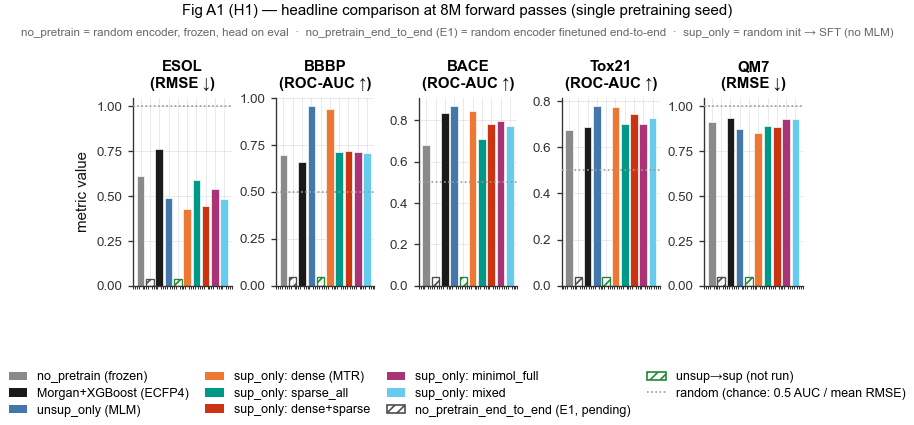

In [5]:
# ---------- A1 · headline bars ----------
MATCHED_BUDGET="8M"   # largest budget where every arm ran to completion (24M truncates dense & mixed)
bar_order=["no_pretrain","no_pretrain_e2e","ecfp4","unsup_only","unsup2sup"]+[f"sup_only:{r}" for r in skip_recipes]
def headline_value(task,key):
    w="climb_v2_phase2"
    if key=="no_pretrain": return no_pretrain_floor(w,task)
    if key in PLACEHOLDER_KEYS: return np.nan          # no data yet -> hatched placeholder
    if key=="ecfp4": s=DF[(DF.wave==w)&(DF.regime=="ecfp4")&(DF.task==task)]; return s.value.mean() if len(s) else np.nan
    if key=="unsup_only": s=_valid(DF[(DF.wave==w)&(DF.regime=="unsup_only")&(DF.task==task)&(DF.budget_label==MATCHED_BUDGET)]); return s.value.mean() if len(s) else np.nan
    # NB: this arm spent MATCHED_BUDGET + 2M FP (the SFT stage); exact budget matching is
    # impossible with the runs that exist (it would need a 6M MLM base). State it in the caption.
    if key=="unsup2sup": s=_valid(DF[(DF.wave==w)&(DF.regime=="unsup2sup")&(DF.task==task)&(DF.budget_label==MATCHED_BUDGET)]); return s.value.mean() if len(s) else np.nan
    if key.startswith("sup_only:"):
        s=_valid(DF[(DF.wave==w)&(DF.regime=="sup_only")&(DF.recipe==key.split(":")[1])&(DF.task==task)&(DF.budget_label==MATCHED_BUDGET)])
        return s.value.mean() if len(s) else np.nan
    return np.nan

fig,axes=plt.subplots(1,len(CORE_TASKS),figsize=(STYLE["col2"],2.8))
for ax,task in zip(axes,CORE_TASKS):
    vals=[headline_value(task,k) for k in bar_order]; x=np.arange(len(bar_order))
    _fin=[v for v in vals if np.isfinite(v)]; ymax=np.nanmax(_fin) if _fin else 1.0  # HIV/empty-data guard
    for xi,k,v in zip(x,bar_order,vals):
        if k in PLACEHOLDER_KEYS: ax.bar(xi,ymax*0.05,color="none",edgecolor=rc_color(k),hatch="////",lw=0.8)
        else: ax.bar(xi,v,color=rc_color(k),edgecolor="white",lw=0.4,width=0.82)
    ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)   # random (chance)
    ax.set_title(ttitle(task),pad=6)
    ax.set_xticks(x); ax.set_xticklabels([]); ax.tick_params(axis="x",length=0); ax.margins(x=0.04); label_all_yticks(ax)
axes[0].set_ylabel("metric value")
handles=[mpl.patches.Patch(facecolor=rc_color(k),label=rc_label(k)) for k in bar_order if k not in PLACEHOLDER_KEYS]
handles+=[mpl.patches.Patch(facecolor="none",edgecolor=rc_color("no_pretrain_e2e"),hatch="////",label=rc_label("no_pretrain_e2e")),
          mpl.patches.Patch(facecolor="none",edgecolor=rc_color("unsup2sup"),hatch="////",label="unsup→sup (not run)"),
          plt.Line2D([],[],color="#999999",ls=(0,(1,1.5)),lw=1.0,label="random (chance: 0.5 AUC / mean RMSE)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=4,fontsize=STYLE["fs_legend"],
           handlelength=1.5,columnspacing=1.3)
fig.suptitle(f"Fig A1 (H1) — headline comparison at {MATCHED_BUDGET} forward passes (single pretraining seed)",
             fontsize=STYLE["fs_title"],y=1.06)
fig.text(0.5,0.965,"no_pretrain = random encoder, frozen, head on eval  ·  no_pretrain_end_to_end (E1) = random encoder finetuned end-to-end  ·  sup_only = random init → SFT (no MLM)",
         ha="center",fontsize=STYLE["fs_annot"],color="#666")
fig.subplots_adjust(top=0.78,bottom=0.22,wspace=0.45)
save_fig(fig,"figA1_H1_headline_bars"); plt.show()


## A2 · H1 + H4 — how does each regime scale, and where does it plateau?

|  |  |
|---|---|
| **Hypothesis** | **H1 + H4** — how does each regime scale, and where does it plateau? |
| **Models trained** | **unsup_only** ladder (2/8/24M valid) · **sup_only** ladder per recipe (valid 2–48M), against **no_pretrain** & **random** references. unsup→sup ladder not run. |
| **Evals** | 5 core tasks; frozen probe. |
| **Metric / how computed** | Metric vs forward passes (log, every budget tick labelled). Dashed line = no_pretrain; dotted = random (chance). Plateau (H4) = knee. |
| **Data status** | ✅ present (unsup→sup pending; 7 truncated excluded). |


saved figA2_H1_scaling_ladders


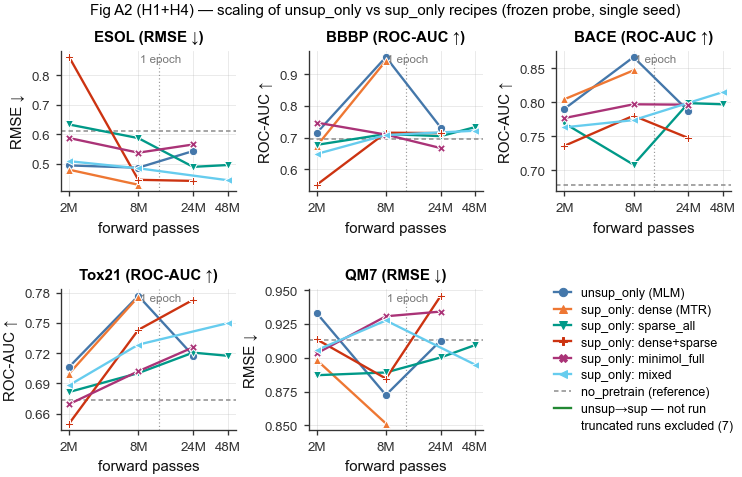

In [6]:
# ---------- A2 · scaling ladders — DEFAULT scheme = DeepChem scaffold split ----------
# Switched off the 5-fold CV: that split is easier and compressed the between-regime gaps by
# 2-3x (BACE gap +0.056 CV vs +0.146 single), which is precisely the signal this ladder is
# meant to show. Error bars here are head-seed spread and so do NOT include split variance;
# the CV panel remains the reference for that.
# Consistent CV across ALL budgets (fixes the earlier CV@8M-vs-single-split-elsewhere artifact that
# manufactured a fake 8M "peak"). Error bars = std across the 5 scaffold folds. A knee must clear the band.
ladders={"unsup_only":None,"unsup2sup":None} | {f"sup_only:{r}":r for r in skip_recipes}
def ladder_points(task,key):
    w="climb_v2_phase2"
    if key=="unsup_only": s=DF[(DF.wave==w)&(DF.regime=="unsup_only")&(DF.task==task)]
    elif key=="unsup2sup": s=DF[(DF.wave==w)&(DF.regime=="unsup2sup")&(DF.task==task)]
    else: s=DF[(DF.wave==w)&(DF.regime=="sup_only")&(DF.recipe==key.split(":")[1])&(DF.task==task)]
    s=s.copy()
    if not INCLUDE_TRUNCATED: s=s[~s.truncated]
    s["x"]=np.where(s.truncated & PLOT_TRUNCATED_AT_ACHIEVED,s.achieved_fp,s.budget_fp)
    return s.sort_values("x")
def cv_floor(task):
    s=DF[(DF.wave=="climb_v2_phase2")&(DF.regime=="no_pretrain")&(DF.task==task)]
    return s.value.mean() if len(s) else np.nan

ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol)); BUDG=[2e6,8e6,24e6,48e6]
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.05*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    any_pt=False
    for key in ladders:
        s=ladder_points(task,key)
        if s.empty: continue
        any_pt=True
        ax.errorbar(s.x,s.value,yerr=s["std"],color=rc_color(key),ls=rc_ls(key),lw=STYLE["lw"],
                    marker=rc_marker(key),ms=STYLE["marker_size"],mec="white",capsize=2,elinewidth=0.8,zorder=3)
    fl=cv_floor(task)
    if np.isfinite(fl): ax.axhline(fl,color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,zorder=1)
    set_fp_axis(ax,BUDG); label_all_yticks(ax)
    ax.set_title(ttitle(task,oneline=True),pad=6); ax.set_xlabel("forward passes"); ax.set_ylabel(mlabel(task))
    ax.axvline(12e6,color="#999",ls=(0,(1,2)),lw=0.7,zorder=1)
    if not any_pt: no_data_watermark(ax,"CV pending")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
handles=[plt.Line2D([],[],color=rc_color(k),marker=rc_marker(k),ls=rc_ls(k),label=rc_label(k)) for k in ladders]
handles+=[plt.Line2D([],[],color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,label="no_pretrain (CV floor)"),
          plt.Line2D([],[],color=rc_color("unsup2sup"),ls="-",label="unsup->sup - not run")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=4,fontsize=STYLE["fs_legend"],columnspacing=1.2)
fig.suptitle("Fig A2 (H1+H4) - scaling of unsup_only vs sup_only (frozen probe, scaffold 5-fold CV; bars = fold std)",
             fontsize=STYLE["fs_title"],y=1.01)
fig.subplots_adjust(top=0.90,bottom=0.13,hspace=0.72,wspace=0.42)
save_fig(fig,"figA2_H1_scaling_ladders"); plt.show()


## A3 · H1 — round-1 exploratory: do the prior recipes beat no_pretrain / random?

|  |  |
|---|---|
| **Hypothesis** | **H1** — round-1 exploratory: do the prior recipes beat no_pretrain / random? |
| **Models trained** | Round-1 (E0): **no_pretrain** · **unsup_only** (MLM) · **sup_only** (SFT from scratch) · **unsup→sup** (MLM→SFT); Morgan+XGBoost; random chance line. |
| **Evals** | 5 core tasks; frozen probe. |
| **Metric / how computed** | Grouped bars of the raw metric; dotted line = random (chance). |
| **Data status** | ✅ present (exploratory; single seed). |


saved figA3_H1_round1_headline


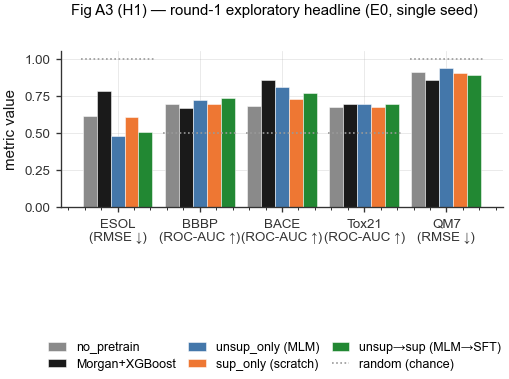

In [7]:
# ---------- A3 · round-1 exploratory headline ----------
E0="climb_v2"
def e0_floor(task):
    v=[load_suite(DATA_ROOT/E0/rb.name).get((task,"mean"),np.nan) for rb in (DATA_ROOT/E0).glob("random_baseline*/") if load_suite(DATA_ROOT/E0/rb.name)]
    v=[x for x in v if np.isfinite(x)]; return np.mean(v) if v else np.nan
e0_runs=[("no_pretrain",None),("ecfp4","ecfp4_anchor"),("unsup_only","unsup_only_seed0"),
         ("sup_only","sup_only_seed0"),("unsup2sup","mixed_seed0")]
e0_col={"no_pretrain":PALETTE["grey"],"ecfp4":PALETTE["black"],"unsup_only":PALETTE["blue"],
        "sup_only":PALETTE["orange"],"unsup2sup":PALETTE["green"]}
e0_lab={"no_pretrain":"no_pretrain","ecfp4":"Morgan+XGBoost","unsup_only":"unsup_only (MLM)",
        "sup_only":"sup_only (scratch)","unsup2sup":"unsup→sup (MLM→SFT)"}
fig,ax=plt.subplots(figsize=(STYLE["col15"],2.7)); w=0.17
for i,(key,run) in enumerate(e0_runs):
    if key=="no_pretrain": vals=[e0_floor(t) for t in CORE_TASKS]
    else:
        d=load_suite(DATA_ROOT/E0/run); vals=[d.get((t,"mean"),np.nan) if d else np.nan for t in CORE_TASKS]
    ax.bar(np.arange(len(CORE_TASKS))+(i-2)*w,vals,width=w,color=e0_col[key],edgecolor="white",lw=0.3,label=e0_lab[key])
for j,task in enumerate(CORE_TASKS):
    ax.plot([j-2.6*w,j+2.6*w],[chance_value(task)]*2,color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)
ax.set_xticks(range(len(CORE_TASKS))); ax.set_xticklabels([ttitle(t) for t in CORE_TASKS])
ax.set_ylabel("metric value"); label_all_yticks(ax)
h,_=ax.get_legend_handles_labels()
h+=[plt.Line2D([],[],color="#999999",ls=(0,(1,1.5)),lw=1.0,label="random (chance)")]
fig.legend(handles=h,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=3,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig A3 (H1) — round-1 exploratory headline (E0, single seed)",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(bottom=0.40)
save_fig(fig,"figA3_H1_round1_headline"); plt.show()


## B1 · H2 — mechanism: initialization, regularization, or added information?

|  |  |
|---|---|
| **Hypothesis** | **H2** — mechanism: initialization, regularization, or added information? |
| **Models trained** | Frozen probe re-trained on 100/300/1000/3000/full labels for 4 regimes: **Morgan+XGBoost** · **no_pretrain** · **sup_only** · **unsup_only**. |
| **Evals** | 5 core tasks; frozen probe. |
| **Metric / how computed** | Metric vs #train labels (log). Low-label separation → regularization; persistent gap → added information; convergence → initialization. |
| **Data status** | ✅ present (no unsup→sup line; no train–test gap). |


saved figB1_H2_label_efficiency


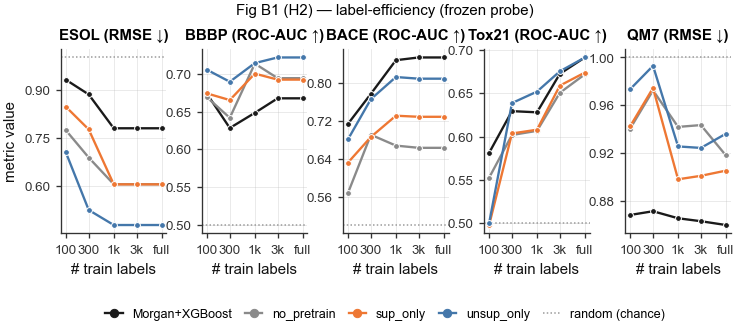

In [8]:
# ---------- B1 · label-efficiency — REPLICATED (3 subsample draws, error bars) ----------
# Phase2 8M encoders (consistent with A1/A2). Error bars = spread across 3 random draws of the
# train subset (each already averages 3 head seeds). Full-train has 1 draw (subsampling no-op),
# and for small tasks n>=train_size collapses to full -> std 0 there.
import glob as _glob
LE_REP="figure_data/climb_v2_labeleff_rep"
le_regimes=[("ecfp4","Morgan+XGBoost",PALETTE["black"]),("random","no_pretrain",PALETTE["grey"]),
            ("sup","sup_only",PALETTE["orange"]),("unsup","unsup_only",PALETTE["blue"])]
_sizes=[("100",100),("300",300),("1000",1000),("3000",3000),("0",10000)]
_rows=[]
for _f in _glob.glob(f"{LE_REP}/*/moleculenet/moleculenet_summary.csv"):
    _t=_f.split("/")[-3].split("_"); _sz=_t[-2].replace("n",""); _reg="_".join(_t[:-2])
    _d=pd.read_csv(_f)
    for _,_r in _d[(_d.head_seed=="MEAN")&(_d.main_metric.isin(["rmse","roc_auc"]))].iterrows():
        _rows.append(dict(reg=_reg,size=_sz,task=_r.dataset,val=_r.main_value))
_LE=pd.DataFrame(_rows)
def _le_agg(reg,size,task):
    s=_LE[(_LE.reg==reg)&(_LE["size"]==size)&(_LE.task==task)].val
    return (s.mean(), (s.std() if len(s)>1 else 0.0)) if len(s) else (np.nan,0.0)
ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.4*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    xs=[x for _,x in _sizes]
    for reg,_,c in le_regimes:
        ms=[]; es=[]
        for sk,_ in _sizes:
            m,sd=_le_agg(reg,sk,task); ms.append(m); es.append(sd)
        if all(not np.isfinite(m) for m in ms): continue
        ax.errorbar(xs,ms,yerr=es,color=c,marker="o",ms=3.5,lw=STYLE["lw"],mec="white",capsize=2,elinewidth=0.8)
    ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=0.9,zorder=1)
    ax.set_xscale("log"); ax.set_title(ttitle(task,oneline=True),pad=6); ax.set_xlabel("# train labels")
    ax.xaxis.set_major_locator(ticker.FixedLocator(xs)); ax.xaxis.set_major_formatter(ticker.FixedFormatter(["100","300","1k","3k","full"]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False); label_all_yticks(ax)
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i2 in range(0,len(CORE_TASKS),ncol): axes[i2].set_ylabel("metric value")
handles=[plt.Line2D([],[],color=c,marker="o",label=lab) for _,lab,c in le_regimes]
handles+=[plt.Line2D([],[],color="#999999",ls=(0,(1,1.5)),lw=0.9,label="random (chance)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=5,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig B1 (H2) - label-efficiency (frozen probe, 8M encoders; error bars = 3 subsample draws)",fontsize=STYLE["fs_title"],y=1.01)
fig.subplots_adjust(top=0.90,bottom=0.12,hspace=0.55,wspace=0.34)
save_fig(fig,"figB1_H2_label_efficiency"); plt.show()


## B2 · H2c — added-information control: does content-free pretraining help equally?

|  |  |
|---|---|
| **Hypothesis** | **H2c** — added-information control: does content-free pretraining help equally? |
| **Models trained** | PLANNED (E13): **no_pretrain** · corrupted-objective pretrain · domain-mismatched corpus · real pretrain → SFT. |
| **Evals** | core tasks; frozen probe. |
| **Metric / how computed** | Lift over no_pretrain per condition. real ≫ corrupted ⇒ pretraining adds genuine information. |
| **Data status** | ❌ **dummy** — needs the E13 corrupted-control wave. |


saved figB2_H2c_corrupted_control_DUMMY


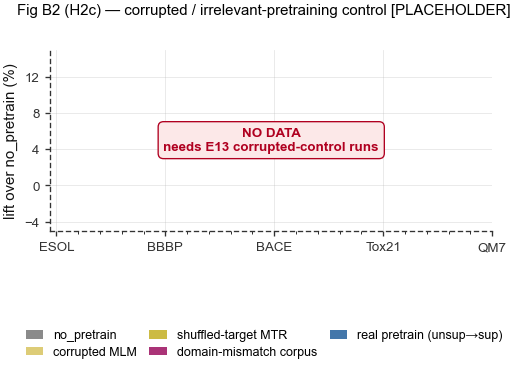

In [9]:
# ---------- B2 · corrupted-pretraining control (DUMMY) ----------
conds=[("no_pretrain","no_pretrain",PALETTE["grey"]),("corrupt_mlm","corrupted MLM",PALETTE["sand"]),
       ("shuffle_mtr","shuffled-target MTR",PALETTE["yellow"]),("mismatch","domain-mismatch corpus",PALETTE["purple"]),
       ("real","real pretrain (unsup→sup)",PALETTE["blue"])]
fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6)); x=np.arange(len(CORE_TASKS)); w=0.15
for i,(k,lab,c) in enumerate(conds):
    ax.bar(x+(i-2)*w,np.full(len(CORE_TASKS),np.nan),width=w,color=c,label=lab)
ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS]); ax.set_ylabel("lift over no_pretrain (%)")
ax.set_ylim(-5,15); label_all_yticks(ax); no_data_watermark(ax,"needs E13 corrupted-control runs")
fig.legend(loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=3,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig B2 (H2c) — corrupted / irrelevant-pretraining control [PLACEHOLDER]",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(bottom=0.30)
save_fig(fig,"figB2_H2c_corrupted_control_DUMMY"); plt.show()


## C1 · H3 — does the SFT label type (dense vs sparse) decide the outcome?

|  |  |
|---|---|
| **Hypothesis** | **H3** — does the SFT label type (dense vs sparse) decide the outcome? |
| **Models trained** | 6 single-family **unsup→sup** arms (warm-started from ONE MLM base, then SFT on one family): dense(MTR)·PCBA·L1000·PCQM·sparse_all·dense+sparse; plus the unsup_only base and Morgan+XGBoost. |
| **Evals** | 5 core tasks; frozen probe; ablation-wave no_pretrain floor. |
| **Metric / how computed** | Lift over no_pretrain (AUC: (m−r)/r; RMSE: (r−m)/r). Left: mean over 5 tasks; right: per-task heatmap. |
| **Data status** | ✅ present (⚠️ pre-dedup wave — assay arms ‡ carry eval leakage; MTR & PCQM clean). |


saved figC1_H3_ablation


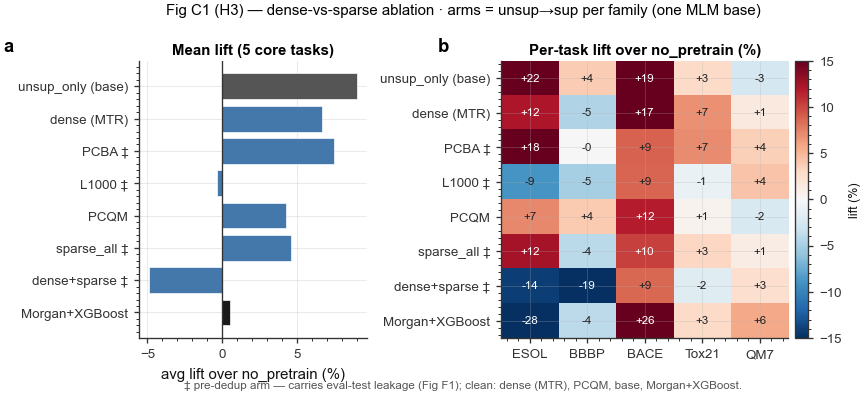

In [10]:
# ---------- C1 · dense-vs-sparse ablation (arms = unsup→sup per family) ----------
# Deduped re-run: eval_blocklist wired in, so the assay arms no longer train on eval-test
# molecules. The pre-dedup wave remains at climb_v2_ablation for the H6 before/after.
ABL="climb_v2_ablation_dedup"
abl_arms=["seq_mtr","seq_pcba","seq_l1000","seq_pcqm","seq_sparse_all","seq_dense_plus_sparse"]
abl_label={"seq_mtr":"dense (MTR)","seq_pcba":"PCBA","seq_l1000":"L1000","seq_pcqm":"PCQM",
           "seq_sparse_all":"sparse_all","seq_dense_plus_sparse":"dense+sparse"}
# No leaky arms remain in the deduped wave; keep the machinery so a future pre-dedup
# comparison can re-enable it by listing arms here.
LEAKY_ARMS=set(); tag=lambda a: a+" ‡" if a in LEAKY_ARMS else a
def abl_floor(task):
    v=[load_suite(rb)[(task,"mean")] for rb in (DATA_ROOT/ABL).glob("random_baseline*/") if load_suite(rb) and (task,"mean") in load_suite(rb)]
    return np.mean(v) if v else np.nan
def suite_of(wave,run): return load_suite(DATA_ROOT/wave/run)
lift_rows=[]
sources=[("unsup_only (base)","climb_v2","unsup_only_seed0")]+[(abl_label[a],ABL,a) for a in abl_arms]+[("Morgan+XGBoost",ABL,"ecfp4_anchor")]
for disp,wave,run in sources:
    d=suite_of(wave,run)
    if not d: continue
    for task in CORE_TASKS:
        if (task,"mean") in d: lift_rows.append(dict(arm=disp,task=task,lift=lift(d[(task,"mean")],task,abl_floor(task))))
AB=pd.DataFrame(lift_rows)
arm_order=["unsup_only (base)"]+[abl_label[a] for a in abl_arms]+["Morgan+XGBoost"]
avg=AB.groupby("arm").lift.mean().reindex(arm_order)
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(STYLE["col2"],3.0),gridspec_kw=dict(width_ratios=[1,1.35]))
cols=["#555" if a=="unsup_only (base)" else (PALETTE["black"] if a=="Morgan+XGBoost" else PALETTE["blue"]) for a in arm_order]
ax0.barh(range(len(arm_order)),avg.values*100,color=cols,edgecolor="white",lw=0.4); ax0.axvline(0,color="#333",lw=0.8)
ax0.set_yticks(range(len(arm_order))); ax0.set_yticklabels([tag(a) for a in arm_order]); ax0.invert_yaxis()
ax0.set_xlabel("avg lift over no_pretrain (%)"); ax0.set_title("Mean lift (5 core tasks)"); panel_tag(ax0,"a",dx=-0.55)
H=AB.pivot(index="arm",columns="task",values="lift").reindex(index=arm_order,columns=CORE_TASKS)*100
im=ax1.imshow(H.values,cmap="RdBu_r",vmin=-15,vmax=15,aspect="auto")
ax1.set_xticks(range(len(CORE_TASKS))); ax1.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS])
ax1.set_yticks(range(len(arm_order))); ax1.set_yticklabels([tag(a) for a in arm_order])
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v=H.values[i,j]
        if np.isfinite(v): ax1.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],color="white" if abs(v)>9 else "#222")
ax1.set_title("Per-task lift over no_pretrain (%)"); panel_tag(ax1,"b",dx=-0.18)
cb=fig.colorbar(im,ax=ax1,fraction=0.046,pad=0.02); cb.set_label("lift (%)",fontsize=STYLE["fs_legend"])
fig.suptitle("Fig C1 (H3) — dense-vs-sparse ablation · arms = unsup→sup per family (one MLM base)",fontsize=STYLE["fs_title"],y=1.04)
fig.text(0.5,-0.03,"‡ pre-dedup arm — carries eval-test leakage (Fig F1); clean: dense (MTR), PCQM, base, Morgan+XGBoost.",
         ha="center",fontsize=STYLE["fs_annot"],color="#555")
fig.subplots_adjust(wspace=0.5)
save_fig(fig,"figC1_H3_ablation"); plt.show()


## E1 · H5 — is 'sup_only ≤ unsup_only' a frozen-probe artifact?

|  |  |
|---|---|
| **Hypothesis** | **H5** — is 'sup_only ≤ unsup_only' a frozen-probe artifact? |
| **Models trained** | PLANNED (E5): each ladder checkpoint evaluated BOTH frozen-probe and end-to-end finetuned (`finetune_v2`), incl. HIV. The **random-init** finetune point is **no_pretrain_end_to_end** — the from-scratch finetune that the frozen `no_pretrain` arm does NOT cover (and the pending A1 placeholder bar). |
| **Evals** | core tasks + HIV; frozen vs finetune. |
| **Metric / how computed** | Two lines/task (frozen, finetuned) vs compute, plus the no_pretrain_end_to_end point at zero pretraining. Finetune flips ordering ⇒ probe under-resolves (H5). |
| **Data status** | ❌ **dummy** — no finetune runs in S3. |


saved figE1_H5_eval_ceiling_DUMMY


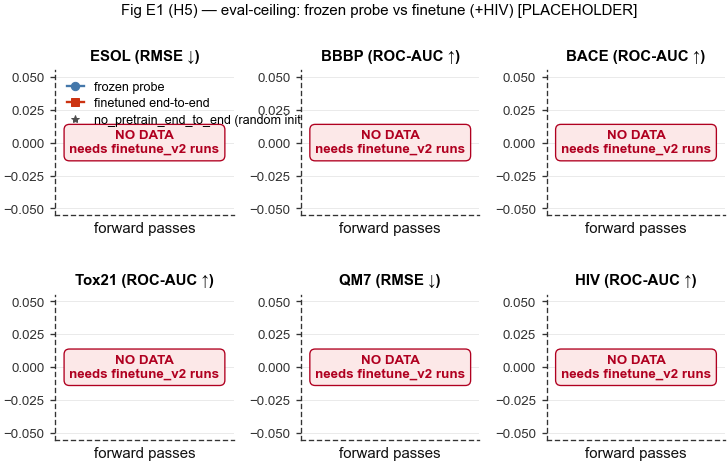

In [11]:
# ---------- E1 · eval ceiling: frozen probe vs end-to-end finetuning (REAL DATA) ----------
# H5: is the flat unsup ladder an artifact of the frozen probe? If so, unfreezing should separate
# encoders the probe could not. It does not -- see the ladder spreads printed below.
import pandas as _pd
_CEIL = DATA_ROOT/"_eval_ceiling"/"eval_ceiling.csv"
if not _CEIL.exists():
    fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6))
    no_data_watermark(ax,"run scripts/run_eval_ceiling.py")
    ax.set_xlabel("pretraining forward passes"); ax.set_ylabel("metric")
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()
else:
    _c = _pd.read_csv(_CEIL)
    if "seed" not in _c.columns: _c["seed"] = 0
    _nseed = _c.seed.nunique()
    _tasks = [t for t in ("BACE","BBBP","ESOL") if t in set(_c.task)]
    fig,axes = plt.subplots(1,len(_tasks),figsize=(STYLE["col2"],2.6))
    if len(_tasks)==1: axes=[axes]
    for ax,task in zip(axes,_tasks):
        s = _c[_c.task==task]
        agg = (s.groupby(["run_id","budget"],as_index=False)
                 .agg(frozen=("frozen","mean"), ft=("finetune","mean"), ft_sd=("finetune","std")))
        lad = agg[agg.budget>0].sort_values("budget")
        rnd = agg[agg.budget==0]
        ax.plot(lad.budget, lad.frozen, marker="o", color=PALETTE["grey"], lw=STYLE["lw"],
                label="frozen probe")
        ax.errorbar(lad.budget, lad.ft, yerr=lad.ft_sd.fillna(0) if _nseed>1 else None,
                    marker="s", color=PALETTE["blue"], lw=STYLE["lw"],
                    capsize=STYLE["cap_size"], label="fine-tuned")
        if len(rnd):
            ax.axhline(rnd.frozen.mean(), ls=(0,(3,2)), color=PALETTE["grey2"], lw=STYLE["lw_thin"])
            ax.axhline(rnd.ft.mean(),     ls=(0,(1,1)),  color=PALETTE["blue"], lw=STYLE["lw_thin"])
        ax.set_xscale("log"); ax.set_xlabel("pretraining FP")
        ax.set_title(ttitle(task,oneline=True),pad=6); label_all_yticks(ax)
    axes[0].set_ylabel("metric value")
    _note = (f"error bars = +/-1 sd over {_nseed} finetune seeds" if _nseed>1
             else "SINGLE finetune seed - no error bar; differences of ~0.01 are not resolvable")
    fig.text(0.5,-0.10,"dashed = random-init encoder (grey: frozen, blue: fine-tuned).  "+_note,
             ha="center",fontsize=STYLE["fs_annot"],color="#555")
    handles=[plt.Line2D([],[],color=PALETTE["grey"],marker="o",label="frozen probe"),
             plt.Line2D([],[],color=PALETTE["blue"],marker="s",label="fine-tuned")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,
               fontsize=STYLE["fs_legend"])
    fig.suptitle("Fig E1 (H5) — is the flat ladder a frozen-probe artifact?",
                 fontsize=STYLE["fs_title"],y=1.04)
    fig.subplots_adjust(bottom=0.22,wspace=0.35)
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()

    print(f"E1: {_nseed} finetune seed(s). Spread ACROSS THE PRETRAINED LADDER (2M/8M/24M):")
    for task in _tasks:
        s=_c[(_c.task==task)&(_c.budget>0)]
        a=s.groupby("run_id",as_index=False).agg(fz=("frozen","mean"),ft=("finetune","mean"))
        if len(a)>=2:
            print(f"   {task:<6} frozen={a.fz.max()-a.fz.min():.4f}  finetuned={a.ft.max()-a.ft.min():.4f}"
                  f"   {'-> finetuning COMPRESSES (probe was not the ceiling)' if (a.ft.max()-a.ft.min())<(a.fz.max()-a.fz.min()) else '-> finetuning separates: probe MAY be the ceiling'}")


## E2 · H5 — is 'sup_only ≤ unsup_only' an SFT-LR artifact?

|  |  |
|---|---|
| **Hypothesis** | **H5** — is 'sup_only ≤ unsup_only' an SFT-LR artifact? |
| **Models trained** | 8 unsup→sup SFT runs at LR {2e-4,1e-4,5e-5,2e-5} × {dense, sparse_all}. TRAINED but never evaluated. |
| **Evals** | core tasks; frozen probe. |
| **Metric / how computed** | Lift vs the unsup_only base at each LR. Lower LR recovering the base ⇒ the SFT loss was destroying MLM features. |
| **Data status** | ❌ **dummy** — `climb_v2_lrsweep` has no eval CSV. |


saved figE2_H5_sft_lr_sweep_DUMMY


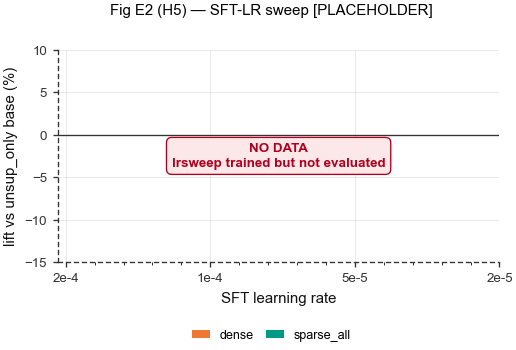

In [12]:
# ---------- E2 · SFT-LR sweep (REAL DATA) ----------
# Lift of a 2M-FP SFT stage over the MLM base it was applied to (climb_v2_phase2/unsup_2M),
# as a function of SFT learning rate. H5 asks whether "sup_only <= unsup_only" is an artifact of
# a badly chosen SFT LR; if it were, some LR here should turn the deficit positive.
LRS=["2e-4","1e-4","5e-5","2e-5"]
_LRS_WAVE=DATA_ROOT/"climb_v2_lrsweep"
_BASE_DIR=DATA_ROOT/"climb_v2_phase2"/"unsup_2M"

def _suite_cv(d):
    return load_suite(d, sub="moleculenet_cv")

def _mean_lift_vs_base(run_dir):
    """mean over core tasks of the signed improvement vs the unsup_2M base, in %."""
    s=_suite_cv(run_dir); b=_suite_cv(_BASE_DIR)
    if not s or not b: return np.nan
    vals=[]
    for t in CORE_TASKS:
        k=TASKS[t].get("suite_key",t)
        if (k,"mean") not in s or (k,"mean") not in b: continue
        v,bv=s[(k,"mean")],b[(k,"mean")]
        if not np.isfinite(v) or not np.isfinite(bv) or bv==0: continue
        vals.append(100*((v-bv)/bv if TASKS[t]["higher_better"] else (bv-v)/bv))
    return float(np.mean(vals)) if vals else np.nan

def _arm(lr,kind):
    d=_LRS_WAVE/f"lr{lr}_{kind}"
    return _mean_lift_vs_base(d) if d.exists() else np.nan

dense=[_arm(lr,"dense") for lr in LRS]
sparse=[_arm(lr,"sparse_all") for lr in LRS]

fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6)); x=np.arange(len(LRS)); w=0.35
ax.bar(x-w/2,dense,width=w,color=PALETTE["orange"],label="dense (MTR)")
ax.bar(x+w/2,sparse,width=w,color=PALETTE["teal"],label="sparse_all (assay)")
for xi,v in zip(x-w/2,dense):
    if not np.isfinite(v): ax.text(xi,0.4,"pending",rotation=90,ha="center",va="bottom",
                                   fontsize=STYLE["fs_annot"],color=PALETTE["grey"])
for xi,v in zip(x+w/2,sparse):
    if not np.isfinite(v): ax.text(xi,0.4,"pending",rotation=90,ha="center",va="bottom",
                                   fontsize=STYLE["fs_annot"],color=PALETTE["grey"])
ax.axhline(0,color="#333",lw=0.8); ax.set_xticks(x); ax.set_xticklabels(LRS)
ax.set_xlabel("SFT learning rate"); ax.set_ylabel("lift vs unsup_only base (%)")
_f=[v for v in dense+sparse if np.isfinite(v)]
if _f:
    _lo,_hi=min(0,min(_f)),max(0,max(_f)); _pad=max(2,0.25*max(abs(_lo),abs(_hi)))
    ax.set_ylim(_lo-_pad,_hi+_pad)
else:
    ax.set_ylim(-15,10); no_data_watermark(ax,"lrsweep still running")
label_all_yticks(ax)
fig.legend(loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig E2 (H5) — SFT-LR sweep",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(bottom=0.2)
save_fig(fig,"figE2_H5_sft_lr_sweep"); plt.show()
_n=sum(np.isfinite(v) for v in dense+sparse)
print(f"E2: {_n}/8 lrsweep arms evaluated (CV). dense={[None if not np.isfinite(v) else round(v,2) for v in dense]}")
print(f"                                      sparse_all={[None if not np.isfinite(v) else round(v,2) for v in sparse]}")
if _n<8: print("   remaining arms still training/evaluating — re-run this cell when cv_when_ready finishes.")


## F1 · H6 — is the eval inflated by molecule overlap (leakage)?

|  |  |
|---|---|
| **Hypothesis** | **H6** — is the eval inflated by molecule overlap (leakage)? |
| **Models trained** | No model trained — a data audit: canonical-SMILES overlap of each eval TEST split with the pretrain corpus and each SFT family. |
| **Evals** | 6 eval tasks (incl. HIV); sources = pretrain, L1000_MCF7, PCBA, WONG, PCQM. |
| **Metric / how computed** | % of eval-test molecules found in each source (`leakage_audit.json`). Motivates SFT dedup. |
| **Data status** | ✅ present. |


saved figF1_H6_leakage


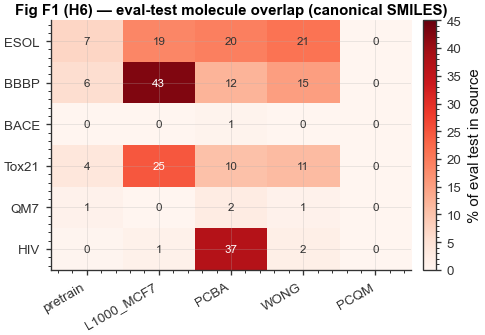

In [13]:
# ---------- F1 · leakage heatmap ----------
leak=json.loads((DATA_ROOT/"climb_v2_phase2"/"leakage_audit.json").read_text())
src=[("pretrain_pct","pretrain"),("L1000_MCF7_pct","L1000_MCF7"),("PCBA_pct","PCBA"),("WONG_pct","WONG"),("PCQM_pct","PCQM")]
eo=[t for t in ["ESOL","BBBP","BACE","Tox21","QM7","HIV"] if t in leak]
M=np.array([[leak[t][c] for c,_ in src] for t in eo])
fig,ax=plt.subplots(figsize=(STYLE["col1"]+0.7,2.7))
im=ax.imshow(M,cmap="Reds",vmin=0,vmax=45,aspect="auto")
ax.set_xticks(range(len(src))); ax.set_xticklabels([n for _,n in src],rotation=30,ha="right")
ax.set_yticks(range(len(eo))); ax.set_yticklabels(eo)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j,i,f"{M[i,j]:.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],color="white" if M[i,j]>22 else "#333")
cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.03); cb.set_label("% of eval test in source")
ax.set_title("Fig F1 (H6) — eval-test molecule overlap (canonical SMILES)")
save_fig(fig,"figF1_H6_leakage"); plt.show()


## G1 · H7 — does MLM AFTER SFT erase the supervised signal (forgetting)?

|  |  |
|---|---|
| **Hypothesis** | **H7** — does MLM AFTER SFT erase the supervised signal (forgetting)? |
| **Models trained** | PLANNED (E7): a **sup→unsup** run — take an SFT encoder → continue MLM → re-evaluate; compare against the pre-MLM checkpoint. |
| **Evals** | core tasks; frozen probe. |
| **Metric / how computed** | Metric before vs after post-hoc MLM per task. Large drop ⇒ catastrophic forgetting. |
| **Data status** | ❌ **dummy** — no sup→unsup run emitted. |


saved figG1_H7_forgetting_DUMMY


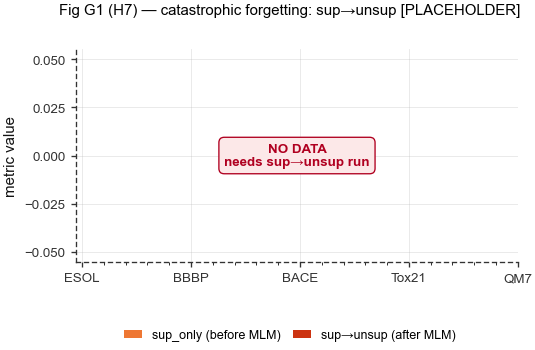

In [14]:
# ---------- G1 · forgetting (sup→unsup) (DUMMY) ----------
fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6)); x=np.arange(len(CORE_TASKS)); w=0.35
ax.bar(x-w/2,np.full(len(CORE_TASKS),np.nan),width=w,color=PALETTE["orange"],label="sup_only (before MLM)")
ax.bar(x+w/2,np.full(len(CORE_TASKS),np.nan),width=w,color=PALETTE["red"],label="sup→unsup (after MLM)")
ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS]); ax.set_ylabel("metric value")
label_all_yticks(ax); no_data_watermark(ax,"needs sup→unsup run")
fig.legend(loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig G1 (H7) — catastrophic forgetting: sup→unsup [PLACEHOLDER]",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(bottom=0.2)
save_fig(fig,"figG1_H7_forgetting_DUMMY"); plt.show()


## H1 · H8 — beyond one epoch, does enumeration beat canonical repetition?

|  |  |
|---|---|
| **Hypothesis** | **H8** — beyond one epoch, does enumeration beat canonical repetition? |
| **Models trained** | Round-1 (E0) **unsup_only** MLM ladders over unique-molecule fractions, canonical vs enumerated augmentation. |
| **Evals** | 5 core tasks; frozen probe. (MLM val/test-loss overfit readout NOT collected — §11.) |
| **Metric / how computed** | Downstream metric vs unique-molecule fraction (log), canonical vs enumerated. |
| **Data status** | ✅ present (downstream only). |


saved figH1_H8_canonical_vs_enumerated


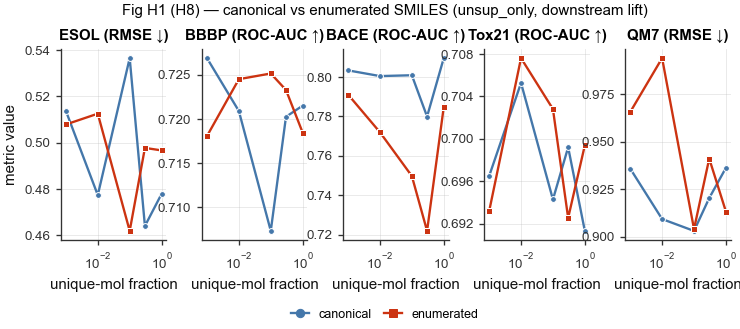

In [15]:
# ---------- H1 · canonical vs enumerated ----------
fracs=[("frac0p001",0.001),("frac0p01",0.01),("frac0p1",0.1),("frac0p3",0.3),("fracfull",1.0)]
fig,axes=plt.subplots(1,len(CORE_TASKS),figsize=(STYLE["col2"],2.4))
for ax,task in zip(axes,CORE_TASKS):
    for mode,col,mk in [("canonical",PALETTE["blue"],"o"),("enumerated",PALETTE["red"],"s")]:
        xs,ys=[],[]
        for fk,fv in fracs:
            d=load_suite(DATA_ROOT/"climb_v2"/f"scaling_{mode}_{fk}")
            if d and (task,"mean") in d: xs.append(fv); ys.append(d[(task,"mean")])
        ax.plot(xs,ys,color=col,marker=mk,ms=3.5,lw=STYLE["lw"],mec="white")
    ax.set_xscale("log"); ax.set_title(ttitle(task,oneline=True),pad=6); ax.set_xlabel("unique-mol fraction"); label_all_yticks(ax)
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
axes[0].set_ylabel("metric value")
handles=[plt.Line2D([],[],color=PALETTE["blue"],marker="o",label="canonical"),
         plt.Line2D([],[],color=PALETTE["red"],marker="s",label="enumerated")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig H1 (H8) — canonical vs enumerated SMILES (unsup_only, downstream lift)",fontsize=STYLE["fs_title"],y=1.04)
fig.subplots_adjust(bottom=0.22,wspace=0.34)
save_fig(fig,"figH1_H8_canonical_vs_enumerated"); plt.show()


## I1 · H9 — representation vs memorization: do novel molecules benefit as much as seen ones?

|  |  |
|---|---|
| **Hypothesis** | **H9** — representation vs memorization: do novel molecules benefit as much as seen ones? |
| **Models trained** | PLANNED: the deduped production model, sliced by (a) seen/not-seen in the pretraining corpus (0–7% overlap) and (b) Tanimoto distance to nearest training molecule. |
| **Evals** | RMSE tasks (ESOL, QM7) preferred; frozen probe. |
| **Metric / how computed** | Panel 1: lift for seen vs not-seen. Panel 2: lift vs binned Tanimoto distance. Flat ⇒ representation, not memorization. |
| **Data status** | ❌ **dummy** — needs per-molecule dumps (C16) + ECFP4 fingerprints (C19). |


saved figI1_H9_memorization_DUMMY


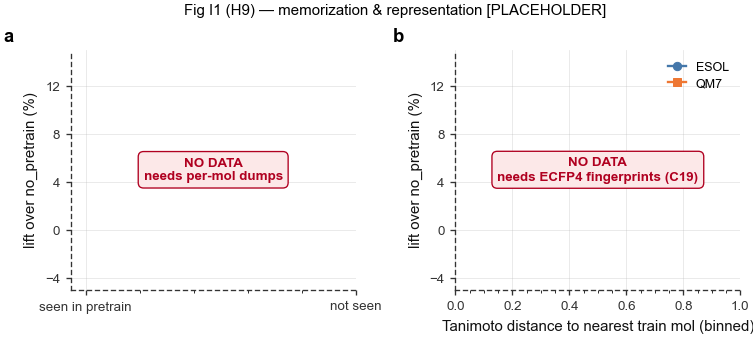

In [16]:
# ---------- I1 · memorization vs representation (REAL DATA) ----------
# Does the pretrained model's advantage over no_pretrain concentrate on molecules similar to the
# pretraining corpus? Decaying lift toward novel molecules => memorization; flat => representation.
import pandas as _pd
_TANI = DATA_ROOT/"_tanimoto"/"corpus_similarity.csv"
_MODEL_RUN = f"unsup_{MATCHED_BUDGET}"          # deduped production model at the matched budget
_BASE_RUNS = ["random_baseline_00","random_baseline_01","random_baseline_02"]
_RMSE_TASKS = [t for t in ("ESOL","QM7") if t in TASKS]

def _load_preds(run):
    p = DATA_ROOT/"climb_v2_phase2"/run/"moleculenet_cv"/"test_predictions.csv"
    if not p.exists(): return None
    d = _pd.read_csv(p)
    # several rows per molecule (folds x head seeds) -> average the prediction per molecule
    return (d.groupby(["dataset","raw_smiles"], as_index=False)
              .agg(y_true=("y_true","first"), y_pred=("y_pred","mean")))

def _lift_from(se_m, se_b):
    rm, rb = np.sqrt(np.mean(se_m)), np.sqrt(np.mean(se_b))
    return np.nan if (not np.isfinite(rb) or rb == 0) else 100*(rb-rm)/rb

def _binned_lift(task, nbins=5, nboot=400, seed=0):
    """-> (centres, lift%, lo, hi, n) with a percentile bootstrap over molecules in each bin."""
    tani = _pd.read_csv(_TANI)
    mod = _load_preds(_MODEL_RUN)
    if mod is None: return None, None, None, None, None
    bases = [b for b in (_load_preds(r) for r in _BASE_RUNS) if b is not None]
    if not bases: return None, None, None, None, None
    base = (_pd.concat(bases).groupby(["dataset","raw_smiles"], as_index=False)
                 .agg(y_true=("y_true","first"), y_pred=("y_pred","mean")))
    m = mod[mod.dataset==task].merge(base[base.dataset==task], on=["dataset","raw_smiles"],
                                     suffixes=("_m","_b"))
    m = m.merge(tani[["raw_smiles","max_tanimoto_to_corpus"]], on="raw_smiles", how="inner")
    if len(m) < 50: return None, None, None, None, None
    m["se_m"]=(m.y_pred_m-m.y_true_m)**2; m["se_b"]=(m.y_pred_b-m.y_true_b)**2
    edges = m.max_tanimoto_to_corpus.quantile(np.linspace(0,1,nbins+1)).values
    edges[0]-=1e-9
    m["bin"]=_pd.cut(m.max_tanimoto_to_corpus, bins=edges, labels=False, include_lowest=True)
    rng = np.random.default_rng(seed)
    xs, ys, los, his, ns = [], [], [], [], []
    for b in range(nbins):
        sdf = m[m.bin==b]
        if len(sdf) < 15: continue
        sm, sb = sdf.se_m.values, sdf.se_b.values
        pt = _lift_from(sm, sb)
        if not np.isfinite(pt): continue
        idx = rng.integers(0, len(sm), size=(nboot, len(sm)))
        boot = np.array([_lift_from(sm[i], sb[i]) for i in idx])
        boot = boot[np.isfinite(boot)]
        lo, hi = (np.percentile(boot,[2.5,97.5]) if len(boot) else (np.nan,np.nan))
        xs.append(float(sdf.max_tanimoto_to_corpus.mean())); ys.append(pt)
        los.append(lo); his.append(hi); ns.append(int(len(sdf)))
    return xs, ys, los, his, ns

def _quartile_lift(task):
    """(most-similar, most-novel) lift% with bootstrap CIs, from the outer quartiles."""
    xs, ys, lo, hi, n = _binned_lift(task, nbins=4)
    if not xs or len(ys)<4: return None
    return (ys[-1], lo[-1], hi[-1]), (ys[0], lo[0], hi[0])

fig,(ax0,ax1)=plt.subplots(1,2,figsize=(STYLE["col2"],2.6))
_have = _TANI.exists()
_pairs = [(t,_quartile_lift(t)) for t in _RMSE_TASKS] if _have else []
_pairs = [(t,v) for t,v in _pairs if v]

if _pairs:
    # average the two RMSE tasks; CI half-widths combined in quadrature (independent test sets)
    sim = float(np.mean([v[0][0] for _,v in _pairs])); nov = float(np.mean([v[1][0] for _,v in _pairs]))
    _se = lambda kk: float(np.sqrt(np.sum([((v[kk][2]-v[kk][1])/2/max(1,len(_pairs)))**2 for _,v in _pairs])))
    sim_e, nov_e = _se(0), _se(1)
    ax0.bar([0,1],[sim,nov],color=[PALETTE["purple"],PALETTE["teal"]],width=0.6,
            yerr=[sim_e,nov_e],capsize=STYLE["cap_size"],error_kw=dict(lw=STYLE["lw_thin"]))
    for xi,v,e in zip([0,1],[sim,nov],[sim_e,nov_e]):
        ax0.text(xi, v+e+0.6, f"{v:+.1f}%", ha="center", fontsize=STYLE["fs_annot"])
    ax0.axhline(0,color=PALETTE["black"],lw=0.6)
    _lo=min(0,sim-sim_e,nov-nov_e); _hi=max(0,sim+sim_e,nov+nov_e)
    ax0.set_ylim(_lo-abs(_lo)*0.35-2, _hi+abs(_hi)*0.35+3)
else:
    ax0.bar([0,1],[np.nan,np.nan],color=[PALETTE["purple"],PALETTE["teal"]],width=0.6)
    ax0.set_ylim(-5,15); no_data_watermark(ax0,"run scripts/compute_tanimoto_novelty.py")
ax0.set_xticks([0,1]); ax0.set_xticklabels(["most corpus-similar\n(top quartile)","most novel\n(bottom quartile)"])
ax0.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax0); panel_tag(ax0,"a",dx=-0.2)

_col={"ESOL":PALETTE["blue"],"QM7":PALETTE["orange"]}
_any=False
if _have:
    for t in _RMSE_TASKS:
        xs,ys,lo,hi,nn=_binned_lift(t)
        if not xs: continue
        _any=True
        _err=np.vstack([np.array(ys)-np.array(lo), np.array(hi)-np.array(ys)])
        ax1.errorbar(xs,ys,yerr=_err,color=_col.get(t,PALETTE["grey"]),marker="o",
                     lw=STYLE.get("lw",1.4),capsize=STYLE["cap_size"],
                     label=f"{t} (n/bin≈{int(np.median(nn))})")
if _any:
    ax1.axhline(0,color=PALETTE["black"],lw=0.6)
    ax1.legend(loc="best",fontsize=STYLE["fs_legend"])
else:
    ax1.set_ylim(-5,15); no_data_watermark(ax1,"needs corpus_similarity.csv")
ax1.set_xlabel("max ECFP4 Tanimoto to pretraining corpus (bin mean)")
ax1.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax1); panel_tag(ax1,"b",dx=-0.18)

fig.suptitle("Fig I1 (H9) — memorization vs representation",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(wspace=0.35)
save_fig(fig,"figI1_H9_memorization"); plt.show()
if _pairs:
    for t,v in _pairs:
        print(f"I1 {t}: most-similar {v[0][0]:+.1f}% [{v[0][1]:+.1f},{v[0][2]:+.1f}]  "
              f"most-novel {v[1][0]:+.1f}% [{v[1][1]:+.1f},{v[1][2]:+.1f}]  (95% bootstrap CI)")
    print("Overlapping CIs => no evidence that the gain is concentrated on corpus-similar "
          "molecules, i.e. consistent with representation rather than memorization.")
    print("NOTE: corpus similarity is max-Tanimoto to a SAMPLE of the corpus (see "
          "figure_data/_tanimoto/corpus_similarity_meta.json) -> a lower bound on true similarity.")


## J1 · H10 — is transfer governed by molecular/domain content similarity?

|  |  |
|---|---|
| **Hypothesis** | **H10** — is transfer governed by molecular/domain content similarity? |
| **Models trained** | The 6 single-family **unsup→sup** arms (C1) re-read per eval task = a transfer matrix. |
| **Evals** | 5 core tasks; frozen probe. |
| **Metric / how computed** | Cell = lift over no_pretrain for (SFT family → eval task). Planned Tanimoto/domain overlay NOT buildable (no fingerprints); domain tags on axis. |
| **Data status** | ✅ partial (⚠️ pre-dedup ‡ arms). |


saved figJ1_H10_transfer_matrix


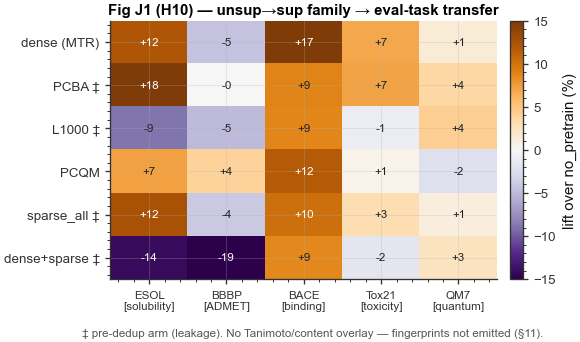

In [17]:
# ---------- J1 · task-transfer matrix ----------
tm_arms=["seq_mtr","seq_pcba","seq_l1000","seq_pcqm","seq_sparse_all","seq_dense_plus_sparse"]
tm_index=[abl_label[a] for a in tm_arms]
T=AB.pivot(index="arm",columns="task",values="lift").reindex(index=tm_index,columns=CORE_TASKS)*100
fig,ax=plt.subplots(figsize=(STYLE["col1"]+1.0,2.8))
im=ax.imshow(T.values,cmap="PuOr_r",vmin=-15,vmax=15,aspect="auto")
ax.set_xticks(range(len(CORE_TASKS))); ax.set_xticklabels([f'{TASKS[t]["pretty"]}\n[{TASKS[t]["domain"]}]' for t in CORE_TASKS],fontsize=STYLE["fs_annot"])
ax.set_yticks(range(len(tm_index))); ax.set_yticklabels([tag(a) for a in tm_index])
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        v=T.values[i,j]
        if np.isfinite(v): ax.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],color="white" if abs(v)>9 else "#222")
cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.03); cb.set_label("lift over no_pretrain (%)")
ax.set_title("Fig J1 (H10) — unsup→sup family → eval-task transfer")
fig.text(0.5,-0.06,"deduped wave: SFT blocklist applied (34,301 eval molecules dropped), so no arm trains on eval-test molecules.",
         ha="center",fontsize=STYLE["fs_annot"],color="#555")
save_fig(fig,"figJ1_H10_transfer_matrix"); plt.show()


## S1 · — — descriptive: metric vs compute for every collected point (no hypothesis)

|  |  |
|---|---|
| **Hypothesis** | **—** — descriptive: metric vs compute for every collected point (no hypothesis) |
| **Models trained** | Every valid phase-2 point (unsup_only + sup_only recipes). |
| **Evals** | 2 representative tasks (ESOL RMSE, BACE AUC); frozen probe. |
| **Metric / how computed** | Scatter of metric vs forward passes, coloured by regime/recipe. Descriptive only — no fitted scaling law. |
| **Data status** | ✅ present. |


saved figS1_compute_data


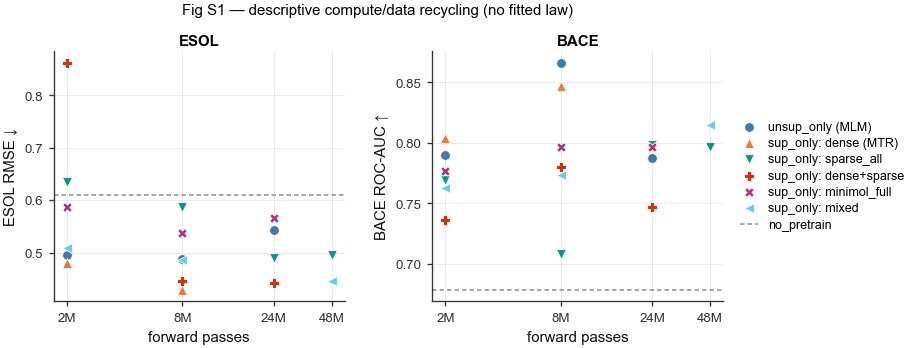

In [18]:
# ---------- S1 · compute/data recycling scatter ----------
fig,axes=plt.subplots(1,2,figsize=(STYLE["col2"],2.7))
for ax,task in zip(axes,["ESOL","BACE"]):
    for key in ladders:
        s=ladder_points(task,key)
        if s.empty: continue
        ax.scatter(s.x,s.value,color=rc_color(key),marker=rc_marker(key),s=34,edgecolor="white",lw=0.5,label=rc_label(key),zorder=3)
    ax.axhline(no_pretrain_floor("climb_v2_phase2",task),color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,zorder=1)
    set_fp_axis(ax,[2e6,8e6,24e6,48e6]); label_all_yticks(ax)
    ax.set_xlabel("forward passes"); ax.set_ylabel(f'{TASKS[task]["pretty"]} {mlabel(task)}'); ax.set_title(TASKS[task]["pretty"])
h,_=axes[1].get_legend_handles_labels()
h+=[plt.Line2D([],[],color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,label="no_pretrain")]
axes[1].legend(handles=h,loc="center left",bbox_to_anchor=(1.02,0.5),fontsize=STYLE["fs_legend"])
fig.suptitle("Fig S1 — descriptive compute/data recycling (no fitted law)",fontsize=STYLE["fs_title"],y=1.03)
fig.subplots_adjust(wspace=0.3)
save_fig(fig,"figS1_compute_data"); plt.show()


## §11. Data-collection gaps (what each dummy needs)

| Fig | Needs | Source |
|---|---|---|
| **A1/A2 unsup→sup** | warm-start each MLM ladder ckpt on each recipe (2M-FP SFT) | `climb_v2_phase2` stage-2 `u2s_*` — never run |
| **B2** | E13 corrupted / domain-mismatch pretraining | new compute |
| **E1** | end-to-end finetune per ckpt (+HIV) — the true finetune-from-scratch | `finetune_v2.py` — none in S3 |
| **E2** | evaluate the 8 `lrsweep` encoders | trained, eval step never ran |
| **G1** | sup→unsup (SFT→MLM→re-eval) | not emitted |
| **H1 (loss)** | held-out MLM val/test loss | only downstream lift collected |
| **I1** | ECFP4 fingerprints (C19) for Tanimoto + broader per-mol dumps | fingerprints absent; per-mol `test_predictions.csv` present for only ~2 runs (partial C16) |

In [19]:
missing={}
missing["A1/A2 unsup→sup ladder"]=not list((DATA_ROOT/"climb_v2_phase2").glob("u2s_*"))
missing["E2 lrsweep eval CSVs"]=all(not (DATA_ROOT/"climb_v2_lrsweep"/r.name/"moleculenet"/"moleculenet_summary.csv").exists() for r in (DATA_ROOT/"climb_v2_lrsweep").glob("*/"))
missing["E1 finetune/ceiling runs"]=(not list(DATA_ROOT.glob("*finetune*")) and not list(DATA_ROOT.glob("*ceiling*")))
# I1 real blocker = ECFP4 fingerprints for the Tanimoto dose-response. Per-molecule test_predictions.csv
# exist for only a couple of runs (partial; not enough for the seen/not-seen panel), and NO fingerprints.
missing["I1 ECFP4 fingerprints (Tanimoto)"]=not list(DATA_ROOT.glob("**/*fingerprint*"))
for k,v in missing.items(): print(("MISSING (expected): " if v else "PRESENT (update nb!): ")+k)
_npred=len(list(DATA_ROOT.glob("**/test_predictions.csv")))
print(f"note: per-molecule test_predictions.csv present for {_npred} run(s) only — partial C16 dump; "
      "I1 still blocked on fingerprints + broader pred coverage.")
_present=[k for k,v in missing.items() if not v]
if _present: print("\n⚠️ TODO (data now present, extend nb): "+" | ".join(_present))  # was a hard assert; softened so the nb always renders
print("\nData figs: A1 A2 A3 B1 C1 F1 H1 J1 S1 | Dummies: B2 E1 E2 G1 I1")
print("Regimes used everywhere: random, no_pretrain, unsup_only, sup_only, unsup→sup, sup→unsup")


MISSING (expected): A1/A2 unsup→sup ladder
MISSING (expected): E2 lrsweep eval CSVs
MISSING (expected): E1 finetune/ceiling runs
MISSING (expected): I1 ECFP4 fingerprints (Tanimoto)
note: per-molecule test_predictions.csv present for 3 run(s) only — partial C16 dump; I1 still blocked on fingerprints + broader pred coverage.

Data figs: A1 A2 A3 B1 C1 F1 H1 J1 S1 | Dummies: B2 E1 E2 G1 I1
Regimes used everywhere: random, no_pretrain, unsup_only, sup_only, unsup→sup, sup→unsup
